[PPO-MM] PyTorch 2.10.0+cpu | Device: cpu

Training: 90° Break Turn
Ep  100 | Reward:     88.1 | Final Alt:   9182m | H-Err:   89°
Ep  200 | Reward:   -200.5 | Final Alt:   9191m | H-Err:  169°
Ep  300 | Reward:   -220.2 | Final Alt:   9233m | H-Err:  157°
Ep  400 | Reward:   -159.8 | Final Alt:   9218m | H-Err:  171°
Ep  500 | Reward:    -25.2 | Final Alt:   9021m | H-Err:   87°

Training: 180° Break Turn
Ep  100 | Reward:     13.7 | Final Alt:   8005m | H-Err:   90°
Ep  200 | Reward:    295.1 | Final Alt:   2787m | H-Err:   25°
Ep  300 | Reward:    718.3 | Final Alt:   3632m | H-Err:    8°
Ep  400 | Reward:    632.1 | Final Alt:   4781m | H-Err:   41°
Ep  500 | Reward:    851.0 | Final Alt:   5372m | H-Err:   22°

Training: Immelmann
Ep  100 | Reward:    -77.6 | Final Alt:   8817m | H-Err:   86°
Ep  200 | Reward:    -74.6 | Final Alt:   8763m | H-Err:   49°
Ep  300 | Reward:     84.2 | Final Alt:   6324m | H-Err:  180°
Ep  400 | Reward:    100.7 | Final Alt:   5984m | H-Err:  102°
Ep

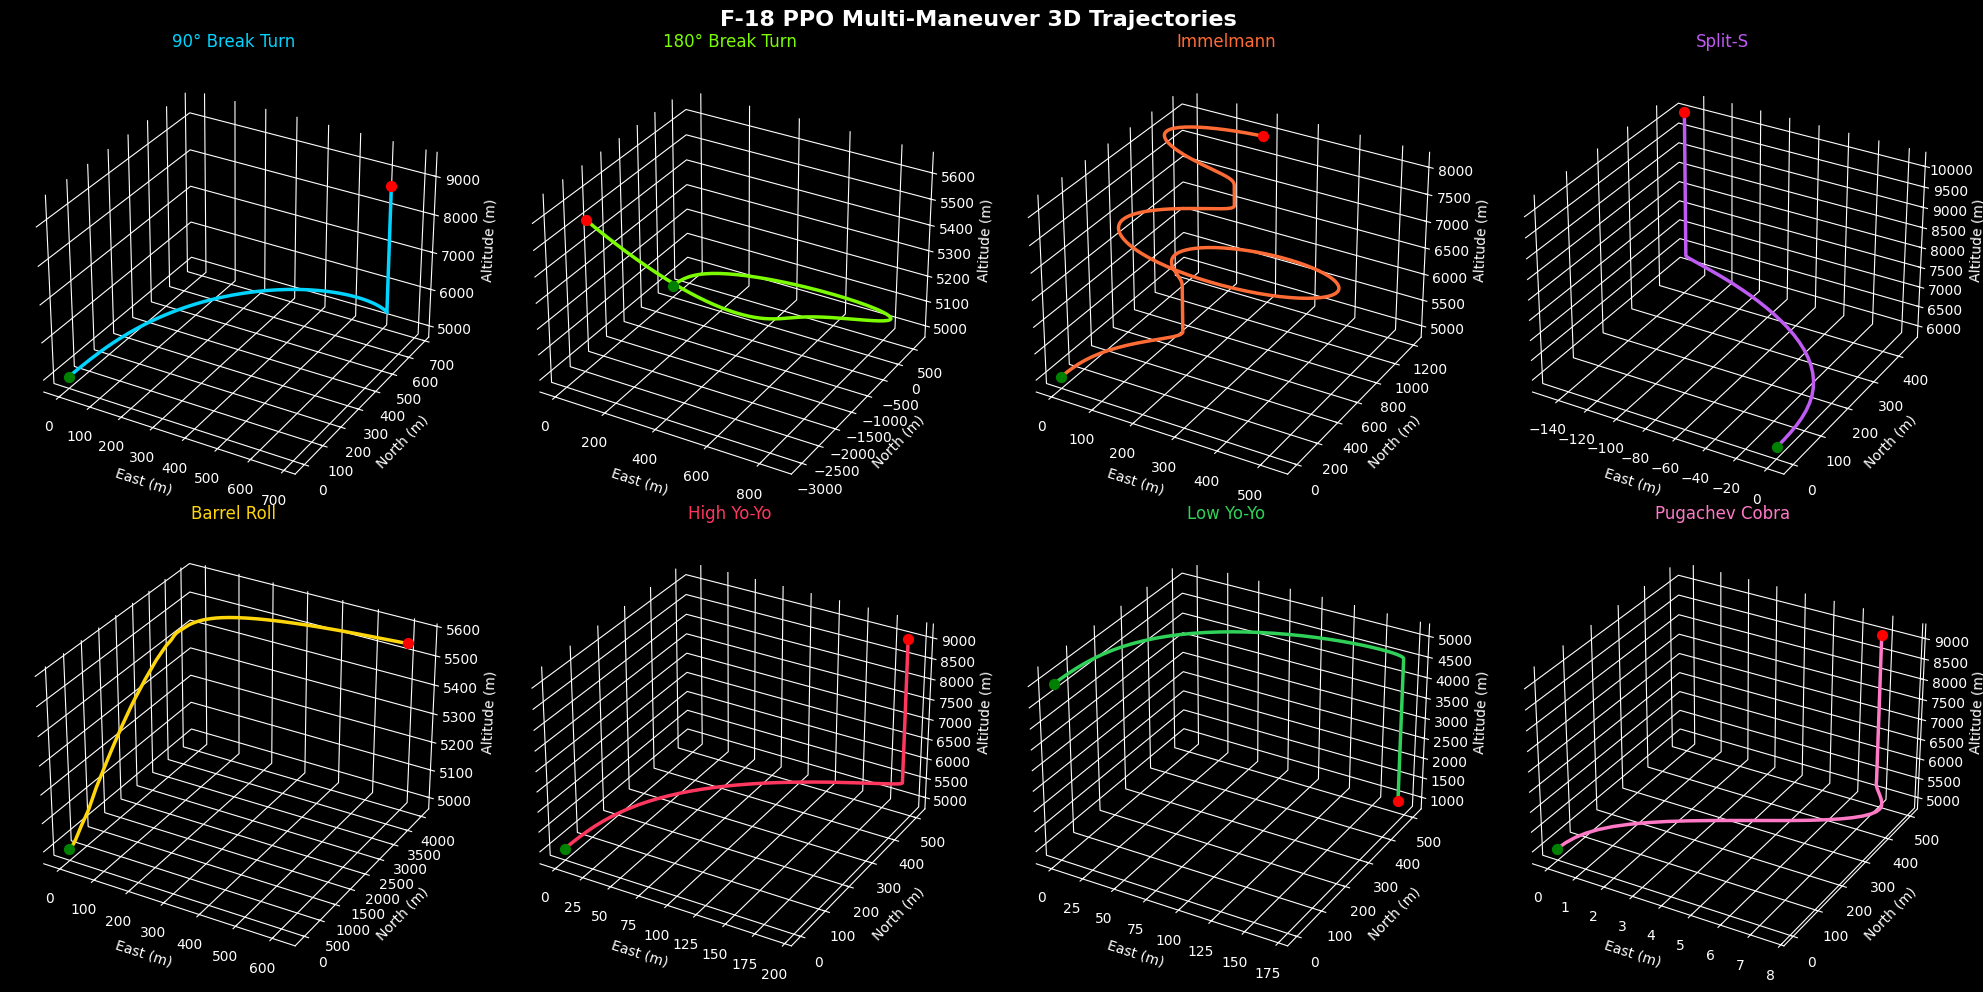

[Saved] ppo_3d_maneuvers.png


In [2]:
"""
=============================================================================
  F-18 HORNET  —  MULTI-MANEUVER PPO
  8 Combat Maneuvers | 12-dim State (6-DOF) | 4-dim Action (Control Surfaces)
=============================================================================
"""

import math
import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Normal
from dataclasses import dataclass, field
from typing import Dict, List, Tuple
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[PPO-MM] PyTorch {torch.__version__} | Device: {DEVICE}")

# ═════════════════════════════════════════════════════════════════════════════
# 1. SHARED 6-DOF KINEMATIC DYNAMICS (12 States, 4 Actions)
# ═════════════════════════════════════════════════════════════════════════════

class F18Dynamics6DOF:
    """
    Simplified 6-DOF kinematic model mapping control surface inputs to
    aerodynamic rates and integrating into a 12-dimensional state vector.
    """
    G = 9.81
    MASS = 16651.0
    V_MIN, V_MAX = 100.0, 600.0

    def __init__(self, dt=0.1):
        self.dt = dt
        self.reset()

    def reset(self, psi0=0.0, h0=5000.0, V0=260.0):
        # 12-DOF State
        self.pos = np.array([0.0, 0.0, h0])          # X (North), Y (East), Z (Alt)
        self.vel = np.array([V0, 0.0, 0.0])          # u (Fwd), v (Side), w (Down)
        self.euler = np.array([0.0, 0.0, psi0])      # phi (Roll), theta (Pitch), psi (Yaw) [deg]
        self.rates = np.array([0.0, 0.0, 0.0])       # p, q, r [deg/s]
        self.steps = 0
        return self._get_state()

    def step(self, action: np.ndarray):
        """
        action: [Elevator, Aileron, Rudder, Throttle] bounded [-1, 1]
        """
        self.steps += 1
        de, da, dr, th = np.clip(action, -1.0, 1.0)

        # 1. Map controls to angular accelerations (simplified aero derivatives)
        p_dot = da * 150.0 - 2.0 * self.rates[0]  # Roll acceleration
        q_dot = de * 60.0  - 2.0 * self.rates[1]  # Pitch acceleration
        r_dot = dr * 30.0  - 1.0 * self.rates[2]  # Yaw acceleration

        # Integrate angular rates
        self.rates += np.array([p_dot, q_dot, r_dot]) * self.dt

        # Integrate Euler angles (phi, theta, psi)
        self.euler += self.rates * self.dt
        self.euler[0] = np.clip(self.euler[0], -180, 180) # Roll limit
        self.euler[1] = np.clip(self.euler[1], -90, 90)   # Pitch limit
        self.euler[2] = self.euler[2] % 360.0             # Heading wraps

        # 2. Map thrust and drag to linear acceleration
        phi_r, theta_r = np.radians(self.euler[0]), np.radians(self.euler[1])

        # Throttle (-1 to 1) mapped to thrust/drag velocity changes
        thrust_accel = ((th + 1.0) / 2.0) * 20.0 - 5.0
        gravity_loss = self.G * np.sin(theta_r)
        drag_loss = 0.0005 * self.vel[0]**2 + 0.1 * abs(self.rates[1])

        u_dot = thrust_accel - gravity_loss - drag_loss
        self.vel[0] = np.clip(self.vel[0] + u_dot * self.dt, self.V_MIN, self.V_MAX)
        self.vel[1] = 0.0 # Simplify sideslip for baseline stability
        self.vel[2] = -self.vel[0] * np.sin(theta_r) # w component

        # Integrate Position
        V_ground = self.vel[0] * np.cos(theta_r)
        x_dot = V_ground * np.cos(np.radians(self.euler[2]))
        y_dot = V_ground * np.sin(np.radians(self.euler[2]))
        z_dot = self.vel[0] * np.sin(theta_r) # Altitude rate

        self.pos += np.array([x_dot, y_dot, z_dot]) * self.dt

        return self._get_state()

    def _get_state(self):
        """Returns normalized 12-DOF state vector."""
        return np.array([
            self.pos[0] / 10000., self.pos[1] / 10000., self.pos[2] / 10000.,
            self.vel[0] / 300., self.vel[1] / 50., self.vel[2] / 50.,
            self.euler[0] / 180., self.euler[1] / 90., self.euler[2] / 360.,
            self.rates[0] / 100., self.rates[1] / 50., self.rates[2] / 50.
        ], dtype=np.float32)

# ═════════════════════════════════════════════════════════════════════════════
# 2. MANEUVER SPECIFICATIONS & REWARD SHAPING
# ═════════════════════════════════════════════════════════════════════════════

@dataclass
class ManeuverSpec:
    name: str
    target_psi: float = 0.0
    target_h: float = 5000.0
    max_steps: int = 400
    w_heading: float = 1.0
    w_pitch: float = 0.0
    w_roll: float = 0.0
    w_alt: float = 0.5
    extra: dict = field(default_factory=dict)

SPECS = {
    'M1_90turn': ManeuverSpec('90° Break Turn', target_psi=90., w_heading=5.0),
    'M2_180turn': ManeuverSpec('180° Break Turn', target_psi=180., w_heading=5.0),
    'M3_immelmann': ManeuverSpec(
        'Immelmann', target_psi=180., target_h=6000.,
        w_pitch=2.0, w_roll=1.0, w_heading=3.0,
        extra={'invert_pitch_target': 80.0}
    ),
    'M4_splitS': ManeuverSpec(
        'Split-S', target_psi=180., target_h=4000.,
        w_pitch=2.0, w_roll=2.0, w_heading=3.0,
        extra={'start_h': 6000.0}
    ),
    'M5_barrel': ManeuverSpec('Barrel Roll', target_psi=0., w_roll=5.0),
    'M6_high_yoyo': ManeuverSpec('High Yo-Yo', target_psi=90., target_h=5500., w_pitch=1.0),
    'M7_low_yoyo': ManeuverSpec('Low Yo-Yo', target_psi=90., target_h=4500., w_pitch=1.0),
    'M8_cobra': ManeuverSpec(
        'Pugachev Cobra', target_psi=0.,
        w_pitch=10.0, w_heading=1.0, extra={'cobra_pitch': 80.0}
    )
}

def compute_reward(dyn: F18Dynamics6DOF, spec: ManeuverSpec):
    """Extensive Reward Shaping based on 12-DOF states."""
    r = 0.0
    phi, theta, psi = dyn.euler
    p, q, yaw_rate = dyn.rates
    h = dyn.pos[2]

    # 1. Heading Alignment
    herr = abs((psi - spec.target_psi + 180) % 360 - 180)
    r += spec.w_heading * np.exp(-herr / 20.0)

    # 2. Altitude Management
    h_err = abs(h - spec.target_h)
    r -= spec.w_alt * (h_err / 1000.0)

    # 3. Maneuver Specific Shaping
    if 'invert_pitch_target' in spec.extra: # Immelmann
        if h < spec.target_h - 200:
            r += spec.w_pitch * np.exp(-abs(theta - spec.extra['invert_pitch_target'])/10.)
        elif theta > 90:
            r += spec.w_roll * abs(p) / 100.0 # Reward rolling when inverted

    elif 'start_h' in spec.extra: # Split-S
        if abs(phi) < 160:
            r += spec.w_roll * abs(p) / 100.0 # Roll inverted first
        else:
            r += spec.w_pitch * np.exp(-abs(theta - (-90.0))/10.) # Pull through

    elif spec.name == 'Barrel Roll':
        r += spec.w_roll * abs(p) / 100.0 # Continuous roll
        r -= abs(theta) / 45.0            # Keep pitch contained

    elif 'cobra_pitch' in spec.extra: # Cobra
        r += spec.w_pitch * np.exp(-abs(theta - spec.extra['cobra_pitch'])/10.)
        if theta > 60 and dyn.vel[0] < 150:
            r += 5.0 # Massive bonus for hitting low speed at high pitch

    # Crash penalty
    if h < 1000.0:
        return -50.0, True

    return r, False

# ═════════════════════════════════════════════════════════════════════════════
# 3. PPO AGENT (Proximal Policy Optimization)
# ═════════════════════════════════════════════════════════════════════════════

class ActorCritic(nn.Module):
    def __init__(self, state_dim=12, action_dim=4):
        super().__init__()
        # Shared Feature Extractor
        self.base = nn.Sequential(
            nn.Linear(state_dim, 256), nn.Tanh(),
            nn.Linear(256, 256), nn.Tanh()
        )
        # Actor Heads
        self.mean_head = nn.Sequential(nn.Linear(256, action_dim), nn.Tanh())
        self.log_std = nn.Parameter(torch.zeros(action_dim))
        # Critic Head
        self.value_head = nn.Linear(256, 1)

    def forward(self, x):
        features = self.base(x)
        action_mean = self.mean_head(features)
        action_std = self.log_std.exp().expand_as(action_mean)
        value = self.value_head(features)
        return action_mean, action_std, value

class PPO:
    def __init__(self, state_dim=12, action_dim=4, lr=3e-4, gamma=0.99, clip=0.2):
        self.gamma = gamma
        self.clip = clip
        self.policy = ActorCritic(state_dim, action_dim).to(DEVICE)
        self.optimizer = optim.Adam(self.policy.parameters(), lr=lr)

    def select_action(self, state):
        state = torch.FloatTensor(state).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            mean, std, _ = self.policy(state)
            dist = Normal(mean, std)
            action = dist.sample()
            log_prob = dist.log_prob(action).sum(dim=-1)
        return action.cpu().numpy().flatten(), log_prob.item()

    def update(self, memory):
        states = torch.FloatTensor(np.array(memory['states'])).to(DEVICE)
        actions = torch.FloatTensor(np.array(memory['actions'])).to(DEVICE)
        old_log_probs = torch.FloatTensor(memory['log_probs']).to(DEVICE)
        rewards = memory['rewards']

        # Calculate Returns & Advantages (Simplified Monte Carlo)
        returns = []
        discounted_sum = 0
        for r in reversed(rewards):
            discounted_sum = r + self.gamma * discounted_sum
            returns.insert(0, discounted_sum)
        returns = torch.FloatTensor(returns).to(DEVICE)
        returns = (returns - returns.mean()) / (returns.std() + 1e-8)

        # Optimize for 4 epochs per rollout
        for _ in range(4):
            mean, std, values = self.policy(states)
            dist = Normal(mean, std)
            log_probs = dist.log_prob(actions).sum(dim=-1)
            entropy = dist.entropy().sum(dim=-1).mean()

            advantages = returns - values.squeeze().detach()

            # PPO Ratio & Clipping
            ratios = torch.exp(log_probs - old_log_probs)
            surr1 = ratios * advantages
            surr2 = torch.clamp(ratios, 1-self.clip, 1+self.clip) * advantages
            actor_loss = -torch.min(surr1, surr2).mean()
            critic_loss = F.mse_loss(values.squeeze(), returns)

            loss = actor_loss + 0.5 * critic_loss - 0.01 * entropy

            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

# ═════════════════════════════════════════════════════════════════════════════
# 4. TRAINING LOOP
# ═════════════════════════════════════════════════════════════════════════════

def train_maneuver(spec_key: str, spec: ManeuverSpec, episodes=1000):
    print(f"\n{'='*50}\nTraining: {spec.name}\n{'='*50}")

    env = F18Dynamics6DOF()
    agent = PPO()

    for ep in range(1, episodes + 1):
        start_h = spec.extra.get('start_h', 5000.0)
        state = env.reset(h0=start_h)
        memory = {'states': [], 'actions': [], 'log_probs': [], 'rewards': []}
        ep_reward = 0
        done = False

        while not done and env.steps < spec.max_steps:
            action, log_prob = agent.select_action(state)
            next_state = env.step(action)
            reward, done = compute_reward(env, spec)

            memory['states'].append(state)
            memory['actions'].append(action)
            memory['log_probs'].append(log_prob)
            memory['rewards'].append(reward)

            state = next_state
            ep_reward += reward

        agent.update(memory)

        if ep % 100 == 0:
            herr = abs((env.euler[2] - spec.target_psi + 180) % 360 - 180)
            print(f"Ep {ep:4} | Reward: {ep_reward:>8.1f} | Final Alt: {env.pos[2]:>6.0f}m | H-Err: {herr:>4.0f}°")

    return agent

# ═════════════════════════════════════════════════════════════════════════════
# 5. TRAJECTORY RECORDING & 3D VISUALIZATION
# ═════════════════════════════════════════════════════════════════════════════

def record_trajectory(agent: PPO, spec: ManeuverSpec) -> dict:
    """Runs a fully trained agent deterministically to record its flight path."""
    env = F18Dynamics6DOF()
    start_h = spec.extra.get('start_h', 5000.0)
    state = env.reset(h0=start_h)

    trajectory = {
        'x': [env.pos[0]],
        'y': [env.pos[1]],
        'z': [env.pos[2]],
        'time': [0.0]
    }

    done = False
    while not done and env.steps < spec.max_steps:
        # For evaluation, we use the mean of the action distribution (deterministic)
        state_tensor = torch.FloatTensor(state).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            mean, _, _ = agent.policy(state_tensor)
            action = mean.cpu().numpy().flatten()

        state = env.step(action)
        _, done = compute_reward(env, spec)

        trajectory['x'].append(env.pos[0])
        trajectory['y'].append(env.pos[1])
        trajectory['z'].append(env.pos[2])
        trajectory['time'].append(env.steps * env.dt)

    return trajectory

def plot_all_3d_trajectories(trained_agents: dict):
    """Plots all 8 maneuvers in a 3D grid."""
    print("\nGenerating 3D trajectory plots...")

    # Set up the matplotlib figure (dark mode for aerospace vibes)
    plt.style.use('dark_background')
    fig = plt.figure(figsize=(20, 10))
    fig.suptitle("F-18 PPO Multi-Maneuver 3D Trajectories", fontsize=16, fontweight='bold')

    # Define a color palette for the 8 maneuvers
    colors = ['#00d4ff', '#7cfc00', '#ff6b35', '#bf5af2',
              '#ffd60a', '#ff375f', '#30d158', '#ff79c6']

    for idx, (key, agent) in enumerate(trained_agents.items()):
        spec = SPECS[key]
        traj = record_trajectory(agent, spec)

        ax = fig.add_subplot(2, 4, idx + 1, projection='3d')

        # Plot the flight path
        ax.plot(traj['y'], traj['x'], traj['z'], color=colors[idx], linewidth=2.5)

        # Mark start (green circle) and end (red square)
        ax.scatter(traj['y'][0], traj['x'][0], traj['z'][0], color='green', s=50, label='Start')
        ax.scatter(traj['y'][-1], traj['x'][-1], traj['z'][-1], color='red', s=50, label='End')

        # Formatting
        ax.set_title(spec.name, color=colors[idx], fontsize=12)
        ax.set_xlabel('East (m)')
        ax.set_ylabel('North (m)')
        ax.set_zlabel('Altitude (m)')

        # Make the panes transparent for better 3D visibility
        ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
        ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
        ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
        ax.grid(color='#30363d', linestyle='--', linewidth=0.5)

    plt.tight_layout()
    plt.savefig("ppo_3d_maneuvers.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("[Saved] ppo_3d_maneuvers.png")

# ═════════════════════════════════════════════════════════════════════════════
# 6. UPDATED MAIN BLOCK
# ═════════════════════════════════════════════════════════════════════════════

if __name__ == "__main__":
    trained_agents = {}

    # Train all 8 policies sequentially
    for key, spec in SPECS.items():
        trained_agents[key] = train_maneuver(key, spec, episodes=500)

    print("\n✓ All 8 PPO Maneuver Policies Trained Successfully.")

    # Plot the trajectories
    plot_all_3d_trajectories(trained_agents)